In [1]:
import os
repo = 'boston-marathons'
counter = 0
max_depth = 50
current = os.getcwd()
while True:
    current_tmp = os.path.basename(os.getcwd())
    if current_tmp == repo:
        print(f"Main dir found: {os.getcwd()}")
        break
    else:
        os.chdir("..")
        counter += 1
        if counter >= max_depth:
            print(f"Reached {max_depth} levels up — '{repo}' not found.")
            os.chdir(current)
            print(f"Current path: {current}")
            break

Main dir found: D:\Scripts\Data Science\projekty\repo\boston-marathons


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as math
from scripts.mappings import continent_colors

In [5]:
df = pd.read_csv('./data/clean/boston_features.csv')
df.head()

,Name,M/F,Age,Age Group,Country,Continent,City,Pace,5K,10K,15K,20K,25K,30K,35K,40K,Official Time,Year,Place_Year,Place_Global
0,"Desisa, Lelisa",M,25,22–25,ETH,Africa,Ambo,3.065431,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.044167,2.154722,2015,1,1
1,"Kirui, Geoffrey",M,24,22–25,KEN,Africa,Keringet,3.075787,0.256944,0.507778,0.762222,1.020833,1.283056,1.550278,1.805278,2.048056,2.160278,2017,1,2
2,"Tsegay, Yemane Adhane",M,30,30–33,ETH,Africa,Addis Ababa,3.086144,0.245278,0.495278,0.749444,1.007778,1.268611,1.533056,1.799722,2.045000,2.163333,2015,2,3
3,"Rupp, Galen",M,30,30–33,USA,North America,Portland,3.086144,0.256667,0.507500,0.762222,1.020833,1.283056,1.550278,1.805278,2.053889,2.166111,2017,2,4
4,"Chebet, Wilson",M,29,26–29,KEN,Africa,Marakwet,3.096500,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.050278,2.172778,2015,3,5


In [7]:
plt.style.use('seaborn-v0_8-whitegrid')

In [9]:
count_dict = df['Country'].value_counts().to_dict()

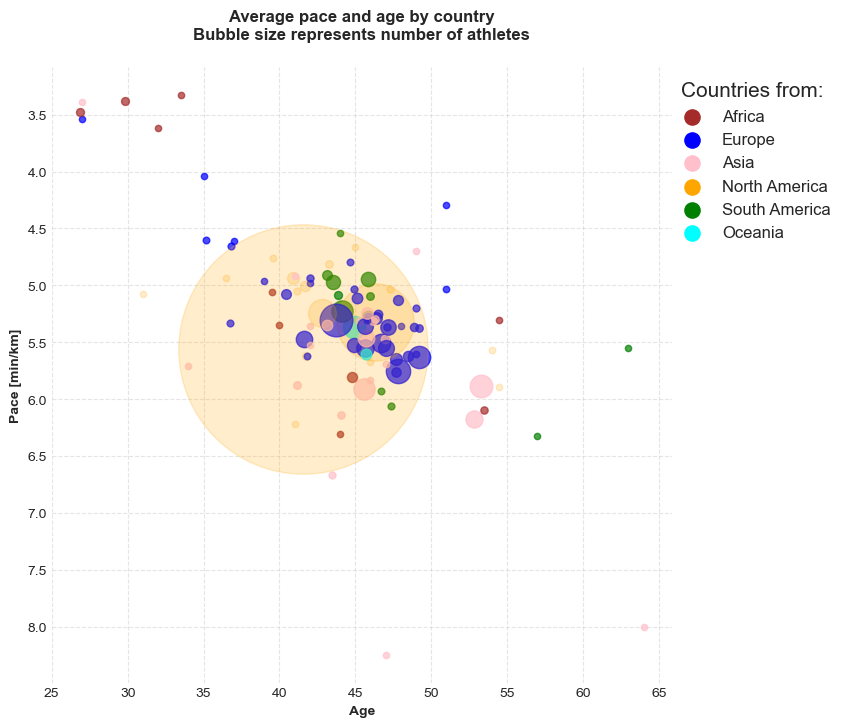

In [11]:
# fig
fig, ax = plt.subplots(figsize=(8,8))
# subset
subset = df[['Country', 'Continent', 'Age', 'Pace']]
subset = subset.groupby(['Country', 'Continent'], as_index=False).agg(
    {
        'Age': 'mean',
        'Pace': 'mean'
    }
)
    
countries = subset['Country']
continents = subset['Continent']
# create plot
for country, continent in zip(countries, continents):
    a = .7
    if continent == 'North America':
        a = 0.2
    x = subset['Age'][countries == country]
    y = subset['Pace'][countries == country]
    plt.scatter(x, y, color=continent_colors[continent], s=(count_dict[country]*.5)+20, alpha=a)
# legend labels    
for continent, color in continent_colors.items():
    # if continent == 'North America':
    #     continue
    plt.scatter([], [], label=continent, color=color, s=120)

## xy settings
# x
ax.set_xlabel('Age', weight='bold')
ax.set_xticks(np.arange(25,66,5))
# # y
ax.set_ylabel('Pace [min/km]', weight='bold')
ax.set_yticks(np.arange(3.5,8.1,.5))
ax.invert_yaxis()

# style
ax.set_title('Average pace and age by country\nBubble size represents number of athletes', weight='bold', pad=20)
ax.grid(True, linestyle='--', alpha=.5)
ax.legend(title='Countries from:', loc='upper right', bbox_to_anchor=(1.28,1), title_fontsize=15, fontsize=12)
ax.spines[['top','bottom','left','right']].set_visible(False)

plt.savefig('charts/bubble_age-pace_country.png', dpi=300, bbox_inches='tight')
plt.show()